# Plot gallery

Plot functions organized by analysis task

Use this gallery to find a plot by analysis task. Each section gives the
relevant functions, the input type used in the example, and a compact
code example. Links point to the workflow pages when more biological or
technical context is useful.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("_includes").resolve()))
from setup import configure_warnings, ensure_matplotlib_initialized
ensure_matplotlib_initialized()
configure_warnings()

import numpy as np
import pandas as pd
import ggnomics as gg
from plotnine import theme_bw, theme, labs, element_text

In [2]:
from data import (
    load_zeisel_subset, run_scranpy_pipeline_on_zeisel, load_baron,
    run_deseq2_on_emtab1625, load_pbmc_cite_seq, run_scranpy_pipeline_on_cite_seq_rna,
    load_tcr_repertoire,
)

zeisel_subset = load_zeisel_subset()
zeisel_final = run_scranpy_pipeline_on_zeisel()
baron = load_baron()
baron_cd = baron.get_column_data().to_pandas()
bulk_fit = run_deseq2_on_emtab1625()
mods, _note = load_pbmc_cite_seq()
cite_final = run_scranpy_pipeline_on_cite_seq_rna()
tcr = load_tcr_repertoire()

Package 'multiassayexperiment' is not installed.

## Reduced dimensions

| Function | Purpose | Type used | Dataset |
|------------------|------------------|------------------|------------------|
| `plot_umap` | UMAP scatter | `SingleCellExperiment` | Zeisel |
| `plot_pca` | PCA scatter | `SingleCellExperiment` | Zeisel |
| `plot_reduced_dim` / `dim_plot` | Generic embedding plot (any key) | `SingleCellExperiment` | Zeisel |
| `sc_pca.run_pca` / `sc_pca.plot_pca` | Single-cell PCA computed via scikit-learn (no scranpy) | `SingleCellExperiment` | Zeisel subset |
| `sc_umap.run_umap` / `sc_umap.plot_umap` | Single-cell UMAP via `umap-learn` | `SingleCellExperiment` | Zeisel subset |
| `bulk_pca.plot_pca` | Bulk/SE PCA | `SummarizedExperiment` | E-MTAB-1625 (VST) |

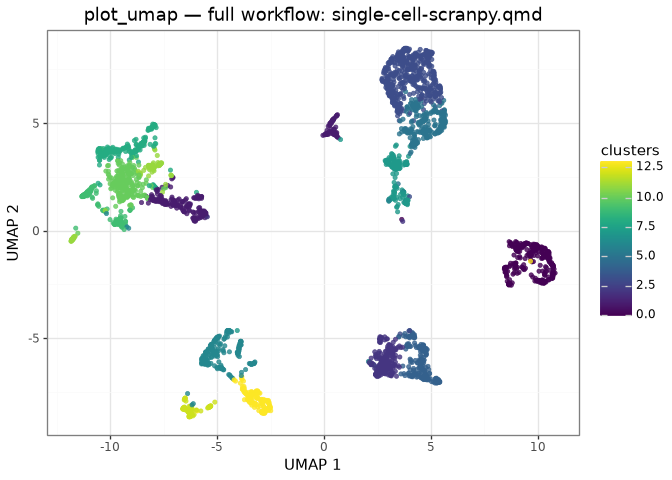

In [3]:
gg.plot_umap(zeisel_final, color="clusters") + theme_bw() + labs(title="plot_umap — full workflow: single-cell-scranpy.qmd")

`plot_reduced_dim` and `dim_plot` are aliases of `plot_embedding`.
`plot_tsne` selects `X_tsne`; here those coordinates were calculated by
`run_all_neighbor_steps_se` together with PCA and UMAP:

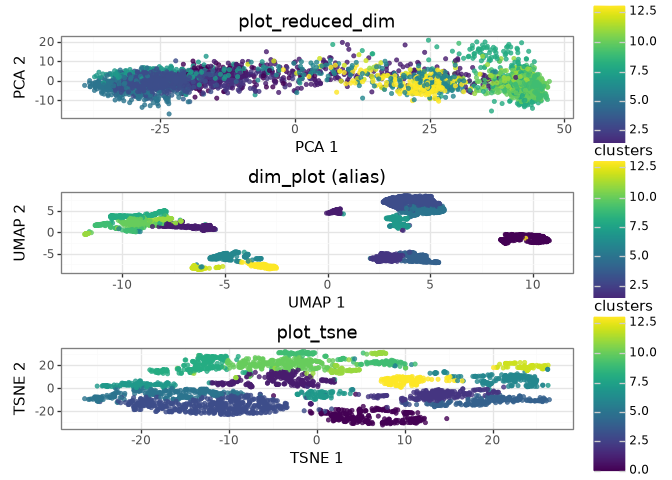

In [4]:
p_reduced = gg.plot_reduced_dim(zeisel_final, dimred="X_pca", color="clusters") + theme_bw() + labs(title="plot_reduced_dim")
p_dim = gg.dim_plot(zeisel_final, dimred="X_umap", color="clusters") + theme_bw() + labs(title="dim_plot (alias)")
p_tsne = gg.plot_tsne(zeisel_final, color="clusters") + theme_bw() + labs(title="plot_tsne")
p_reduced / p_dim / p_tsne

`ggnomics.sc_pca` and `ggnomics.sc_umap` provide PCA and UMAP through
scikit-learn and umap-learn, without a scranpy dependency. The top-level
`ggnomics.plot_pca` only displays coordinates already stored in the
input object.

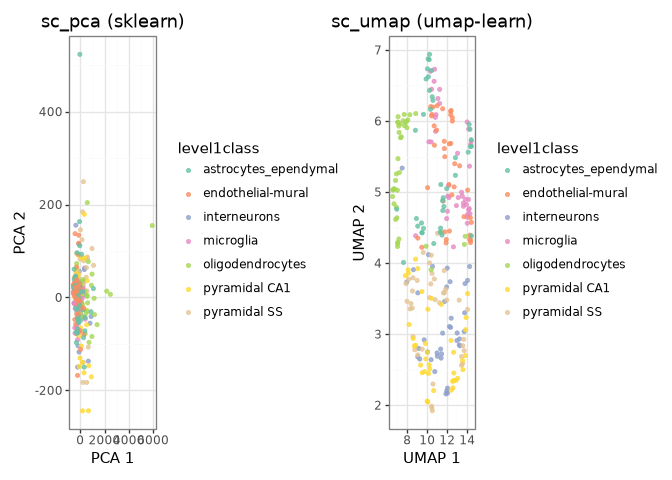

In [5]:
sub2 = load_zeisel_subset()
gg.sc_pca.run_pca(sub2, assay_name="counts", dest_key="PCA", n_components=10)
gg.sc_umap.run_umap(sub2, assay_name="counts", dest_key="UMAP")
p_pca = gg.sc_pca.plot_pca(sub2, color="level1class") + theme_bw() + labs(title="sc_pca (sklearn)")
p_umap = gg.sc_umap.plot_umap(sub2, color="level1class") + theme_bw() + labs(title="sc_umap (umap-learn)")
p_pca | p_umap

`bulk_pca.plot_pca` is demonstrated in full in [Bulk RNA-seq
§7](bulk-rnaseq.ipynb#7.-PCA-on-the-VST-transformed-expression).

## Expression distributions

| Function | Purpose | Type used | Dataset |
|------------------|------------------|------------------|------------------|
| `plot_expression` | Faceted violin per feature/group | `SingleCellExperiment` | Zeisel |
| `plot_violin_stats` | Violin + automatic significance brackets | `pd.DataFrame` | Zeisel |
| `plot_box_stats` | Box + automatic significance brackets | `pd.DataFrame` | Zeisel |
| `expression_violin` (legacy) | Predecessor of `plot_expression` | `pd.DataFrame` | Zeisel |
| `ridge_density` (legacy, no modern replacement) | KDE ridge plot per group | `pd.DataFrame` | Zeisel |

See [Specialized
plots](specialized-plots.ipynb#Zeisel:-statistics,-significance-brackets,-dot-plots,-palettes)
for statistical annotations and significance brackets.

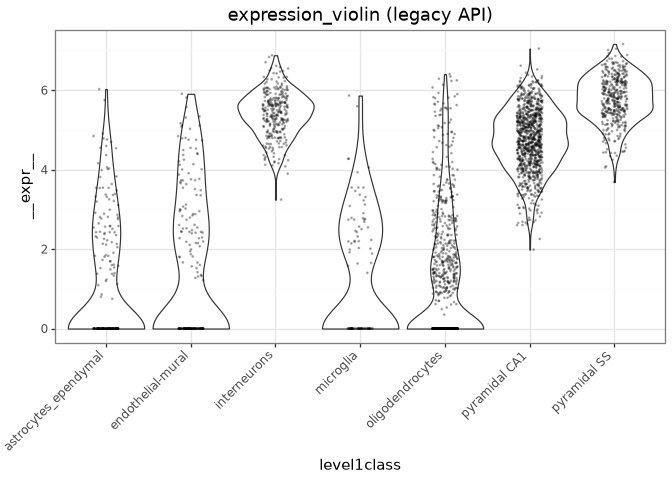

In [6]:
cd = zeisel_final.column_data.to_pandas()
gg.expression_violin(cd.assign(Snap25=np.asarray(zeisel_final.get_assay("logcounts")[list(zeisel_final.get_row_names()).index("Snap25"), :]).ravel()), value="Snap25", group="level1class") + theme_bw() + theme(axis_text_x=element_text(rotation=45, hjust=1)) + labs(title="expression_violin (legacy API)")

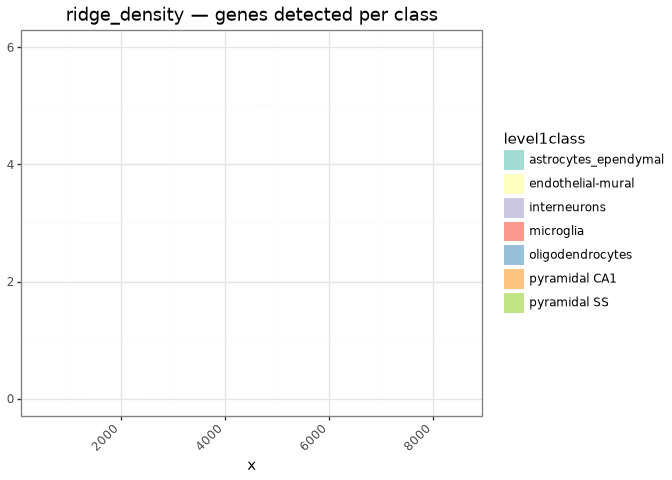

In [7]:
gg.ridge_density(cd, value="detected", group="level1class") + theme_bw() + theme(axis_text_x=element_text(rotation=45, hjust=1)) + labs(title="ridge_density — genes detected per class")

## Metadata plots

| Function | Purpose | Type used | Dataset |
|------------------|------------------|------------------|------------------|
| `plot_coldata` | obs/colData scatter, violin, box, bar, strip | `SingleCellExperiment` | Zeisel |
| `plot_rowdata` | var/rowData scatter | `SingleCellExperiment` | Zeisel (HVG stats) |
| `qc_scatter` (legacy) | Simple QC scatter | `pd.DataFrame` | Zeisel |
| `qc_histogram` (legacy) | Histogram of one column | `pd.DataFrame` | Zeisel |

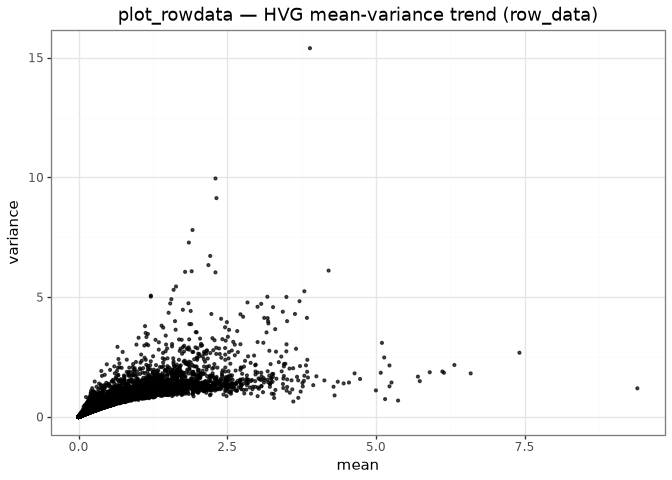

In [8]:
gg.plot_rowdata(zeisel_final, x="mean", y="variance") + theme_bw() + labs(title="plot_rowdata — HVG mean-variance trend (row_data)")

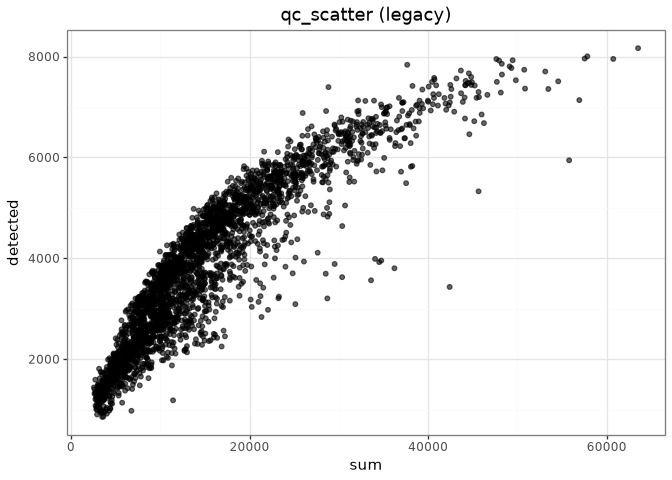

In [9]:
gg.qc_scatter(cd, x="sum", y="detected") + theme_bw() + labs(title="qc_scatter (legacy)")

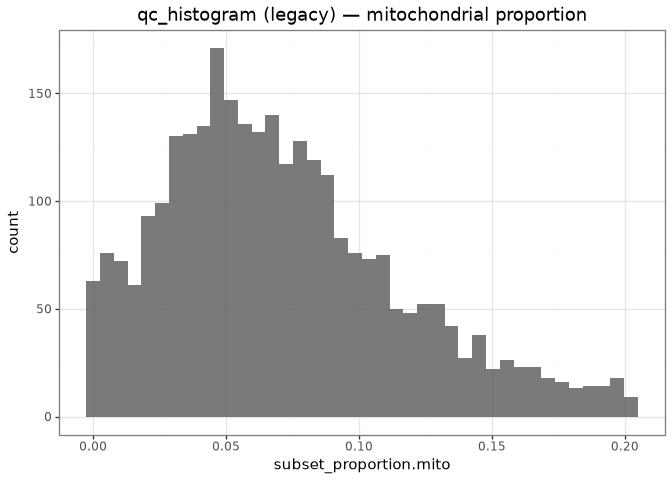

In [10]:
gg.qc_histogram(cd, value="subset_proportion.mito", bins=40) + theme_bw() + labs(title="qc_histogram (legacy) — mitochondrial proportion")

## Scatter plots

| Function | Purpose | Type used | Dataset |
|------------------|------------------|------------------|------------------|
| `plot_scatter` | General x/y scatter | `SingleCellExperiment` | Zeisel |
| `plot_scatter_marginal` | Scatter + marginal densities (`Compose`) | `pd.DataFrame` | Zeisel |
| `plot_pairs` | Scatterplot matrix of embedding components | `SingleCellExperiment` | Zeisel subset |
| `plot_embedding_panel` | Grid of embedding panels, one per feature (`Compose`) | `SingleCellExperiment` | Zeisel |

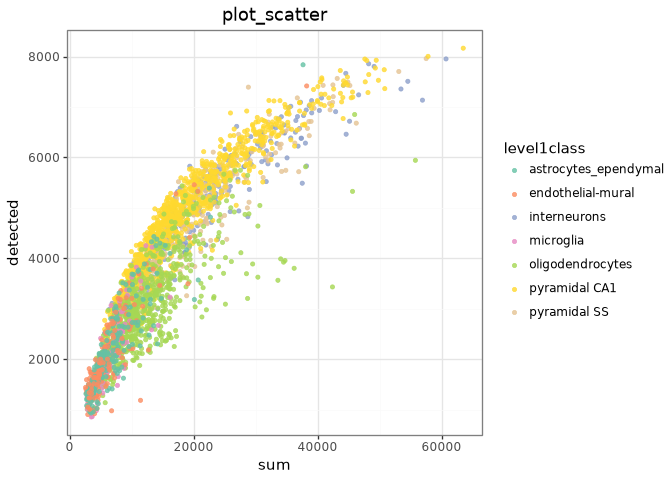

In [11]:
gg.plot_scatter(cd, x="sum", y="detected", color="level1class") + theme_bw() + labs(title="plot_scatter")

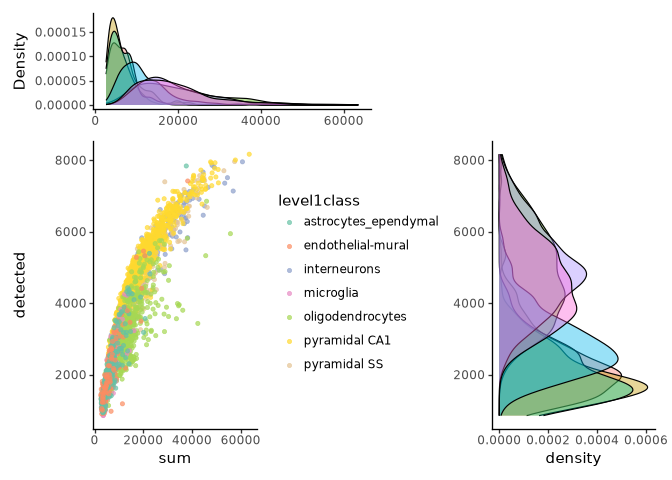

In [12]:
gg.plot_scatter_marginal(cd, x="sum", y="detected", color="level1class")

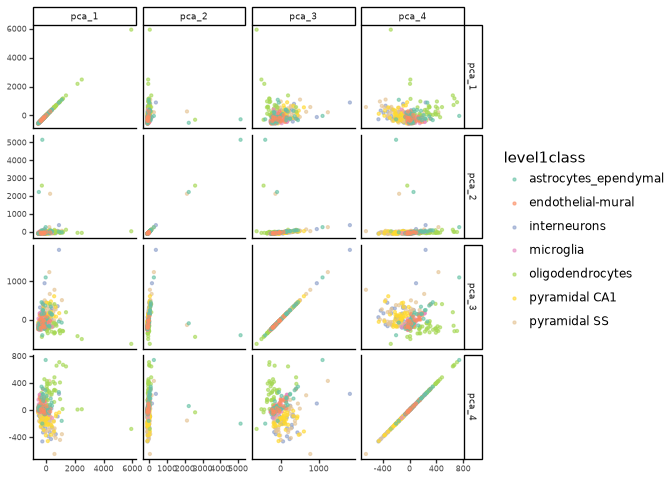

In [13]:
gg.plot_pairs(sub2, dimred="X_pca", n_components=4, color_by="level1class")

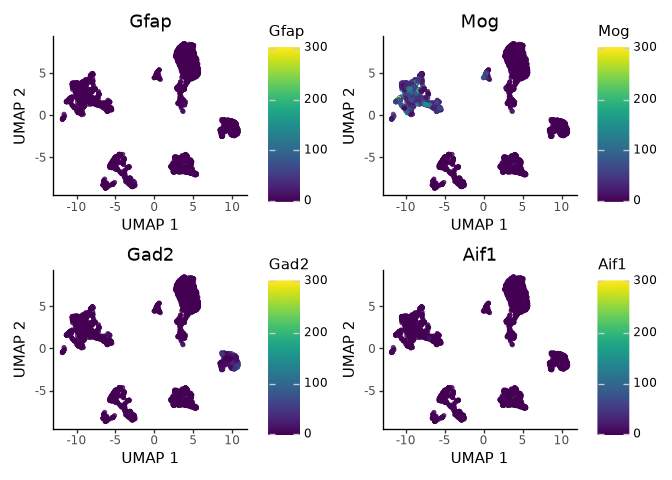

In [14]:
gg.plot_embedding_panel(zeisel_final, features=["Gfap", "Mog", "Gad2", "Aif1"], dimred="X_umap", ncol=2)

## Abundance and composition

Counts, fractions, and donor-aware grouping are shown in [Specialized
plots](specialized-plots.ipynb#Baron-pancreas:-abundance,-composition,-and-pseudobulk).

| Function | Purpose | Type used | Dataset |
|------------------|------------------|------------------|------------------|
| `plot_abundance` | Stacked composition bar | `pd.DataFrame` | Baron |
| `cluster_composition_barplot` (legacy) | Predecessor of `plot_abundance` | `pd.DataFrame` | Baron |

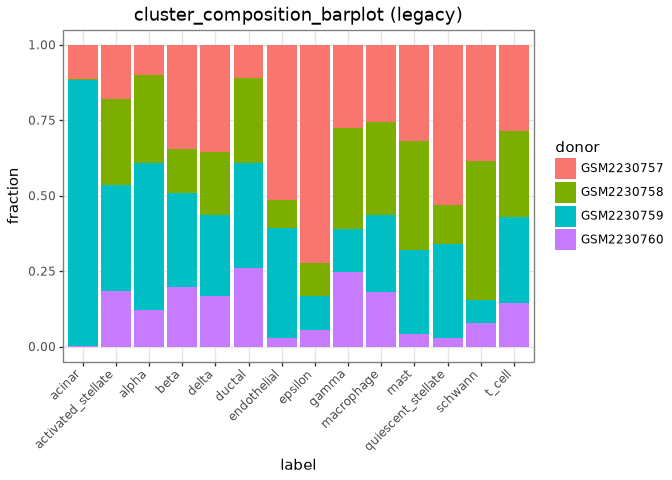

In [15]:
gg.cluster_composition_barplot(baron_cd, cluster_col="label", group_col="donor") + theme_bw() + theme(axis_text_x=element_text(rotation=45, hjust=1)) + labs(title="cluster_composition_barplot (legacy)")

## QC

`plot_pseudobulk_qc` is demonstrated with the four Baron donors in
[Specialized
plots](specialized-plots.ipynb#Donor-aware-grouping-and-pseudobulk-QC).
RNA and ADT quality-control plots are covered separately in
[Multimodal](multimodal.ipynb#5.-RNA-QC-and-ADT-QC).

## Dot plots

| Function | Purpose | Type used | Dataset |
|------------------|------------------|------------------|------------------|
| `plot_dot` | Mean expression x fraction expressing | `SingleCellExperiment` | Zeisel |
| `marker_dotplot` (legacy) | Tidy-table dot plot | `pd.DataFrame` | Zeisel |
| `marker_dotplot_from_matrix` (legacy) | Matrix-in dot plot | `np.ndarray` | Zeisel |

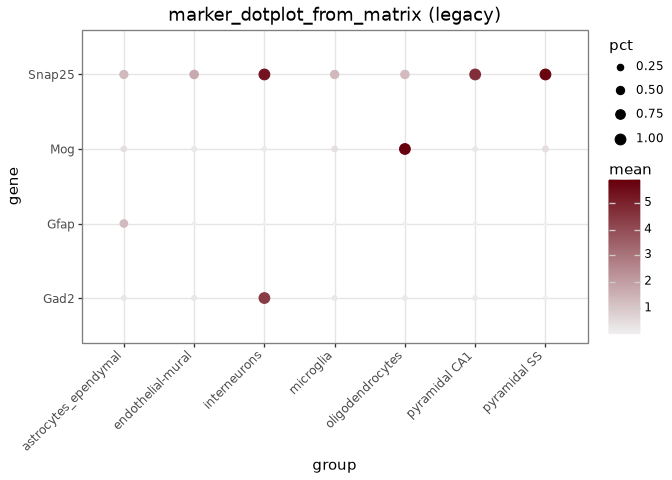

In [16]:
markers = ["Gfap", "Mog", "Gad2", "Snap25"]
gfap_idx = [list(zeisel_final.get_row_names()).index(g) for g in markers]
expr_mat = np.asarray(zeisel_final.get_assay("logcounts")[gfap_idx, :])
expr_df = pd.DataFrame(expr_mat.T, columns=markers)
p = gg.marker_dotplot_from_matrix(expr_df, groups=cd["level1class"].to_numpy(), genes=markers, expr_threshold=0.1)
p + theme_bw() + theme(axis_text_x=element_text(rotation=45, hjust=1)) + labs(title="marker_dotplot_from_matrix (legacy)")

## Highest-expressed features

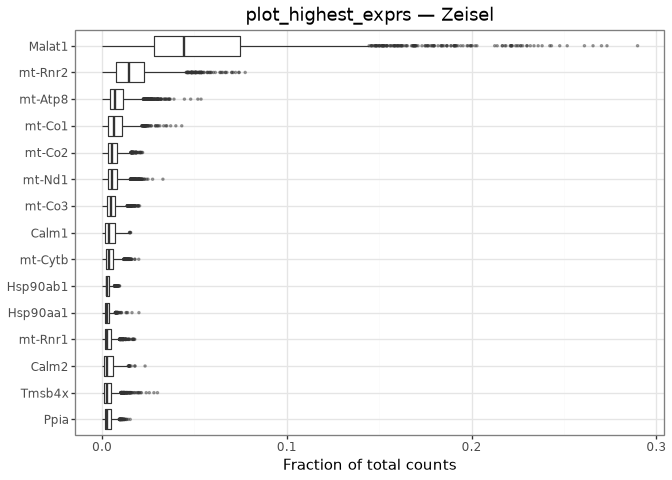

In [17]:
gg.plot_highest_exprs(zeisel_final, n=15, layer="counts") + theme_bw() + labs(title="plot_highest_exprs — Zeisel")

## Heatmaps

| Function | Purpose | Type used | Dataset |
|------------------|------------------|------------------|------------------|
| `plot_heatmap` | Expression heatmap, optional clustering | `SingleCellExperiment`/`pd.DataFrame` | Zeisel, Baron, E-MTAB-1625 |
| `heatmap_from_matrix` (legacy) | Matrix-in heatmap | `np.ndarray` | Zeisel |
| `heatmap_long` (legacy) | Tidy long-format heatmap | `pd.DataFrame` | Zeisel |
| Marsilea (`ma.Heatmap`) | Composable clustered heatmap (interop, not wrapped by ggnomics) | `np.ndarray` | E-MTAB-1625 |

For grouped, bulk, and Marsilea heatmaps, see: [Single-cell analysis
§11](single-cell-scranpy.ipynb#11.-Heatmap), [Bulk RNA-seq
§10](bulk-rnaseq.ipynb#10.-Heatmap-of-top-differentially-expressed-genes),
[Specialized plots](specialized-plots.ipynb#Marsilea-backed-heatmap).

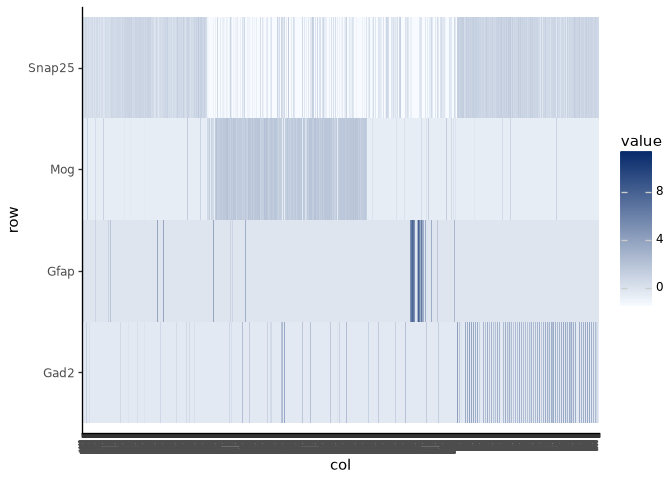

In [18]:
gg.heatmap_from_matrix(expr_mat, row_names=markers, col_names=None, zscore_rows=True) + theme(axis_text_x=element_text(size=3))

## Differential expression

The complete analysis is shown in [Bulk RNA-seq](bulk-rnaseq.ipynb), with
additional visualizations in [Specialized
plots](specialized-plots.ipynb#E-MTAB-1625:-differential-expression-results).

| Function | Purpose | Type used | Dataset |
|------------------|------------------|------------------|------------------|
| `plot_volcano` | Volcano plot | `pd.DataFrame` (PyDESeq2 results) | E-MTAB-1625 |
| `plot_ma` | MA plot | `pd.DataFrame` | E-MTAB-1625 |
| `plot_coef_lollipop` | Top-n coefficients, lollipop | `pd.Series`/`pd.DataFrame` | E-MTAB-1625 |
| `plot_coef_expression` | Expression of top-coefficient features | `pd.DataFrame` | E-MTAB-1625 |
| `volcano_plot` (legacy) | Predecessor of `plot_volcano` | `pd.DataFrame` | E-MTAB-1625 |

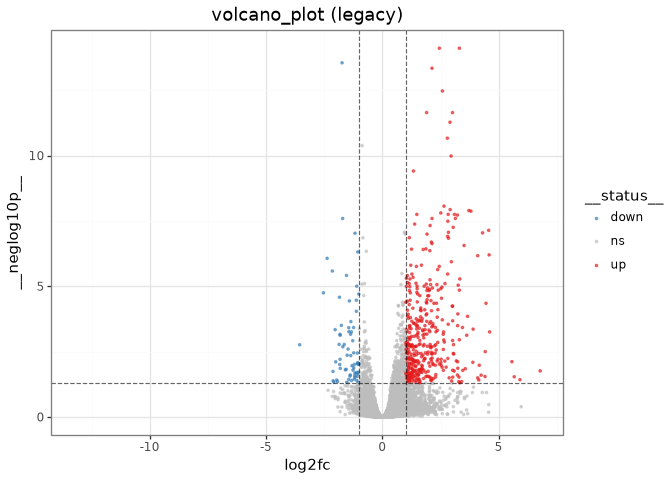

In [19]:
results = bulk_fit["results"]
gg.volcano_plot(results.rename(columns={"log2FoldChange": "log2fc", "padj": "padj"}), log2fc="log2fc", padj="padj") + theme_bw() + labs(title="volcano_plot (legacy)")

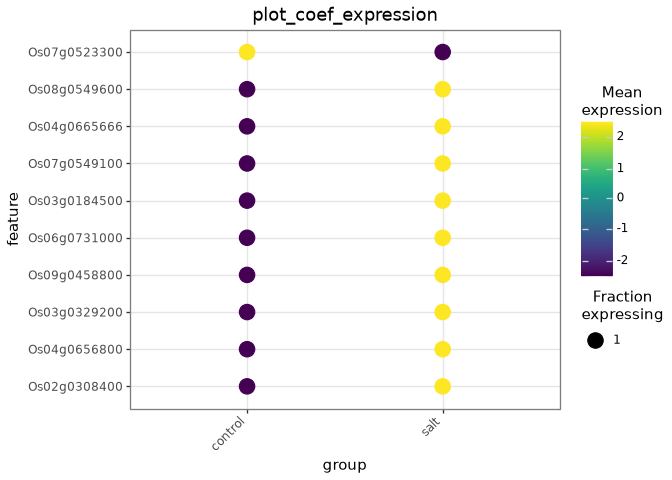

In [20]:
coefs = results[["log2FoldChange"]].rename(columns={"log2FoldChange": "coefficient"}).dropna()
data = bulk_fit["vst"].copy()
data["growth_condition"] = bulk_fit["metadata"]["growth_condition"].to_numpy()
gg.plot_coef_expression(data, coefs, group_by="growth_condition", top_n=10, plot_type="dot") + theme_bw() + theme(axis_text_x=element_text(rotation=45, hjust=1)) + labs(title="plot_coef_expression")

## Pseudobulk

`plot_pseudobulk_qc` is fully covered on Baron in [Specialized
plots](specialized-plots.ipynb#Donor-aware-grouping-and-pseudobulk-QC).
`plot_pseudobulk_de` accepts a `dict[str, DataFrame]` of differential-
expression results. Here the keys identify the three E-MTAB-1625 time
points:

In [21]:
per_timepoint = {tp: run_deseq2_on_emtab1625(tp)["results"] for tp in ["1 hour", "5 hour", "24 hour"]}
results_by_tp = {tp.replace(" ", "_"): df for tp, df in per_timepoint.items()}
{k: int((df["padj"] < 0.05).sum()) for k, df in results_by_tp.items()}

{'1_hour': 14, '5_hour': 8, '24_hour': 832}

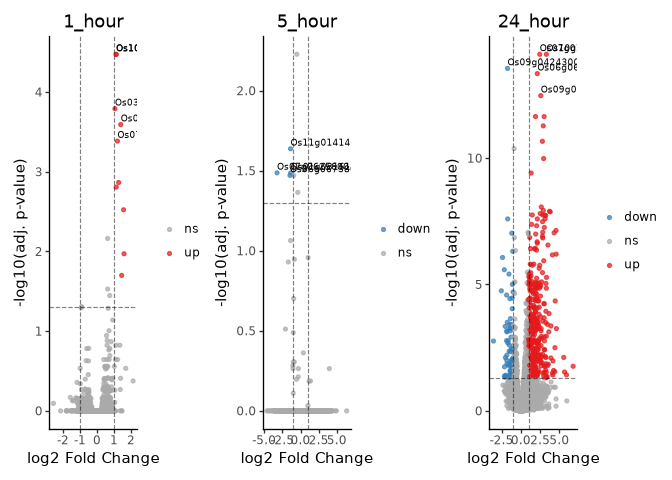

In [22]:
gg.plot_pseudobulk_de(results_by_tp, mode="volcano", ncol=3)

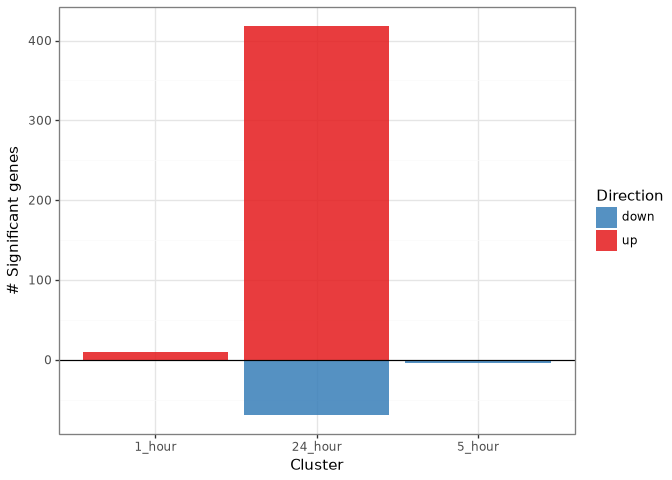

In [23]:
gg.plot_pseudobulk_de(results_by_tp, mode="summary_bar") + theme_bw()

`mode="upset"` uses the native `ggnomics.upset` backend (part of the
normal package — no extra install required for plotting) and returns an
ordinary `plotnine.composition.Compose`, showing which significant genes
are shared across timepoints:

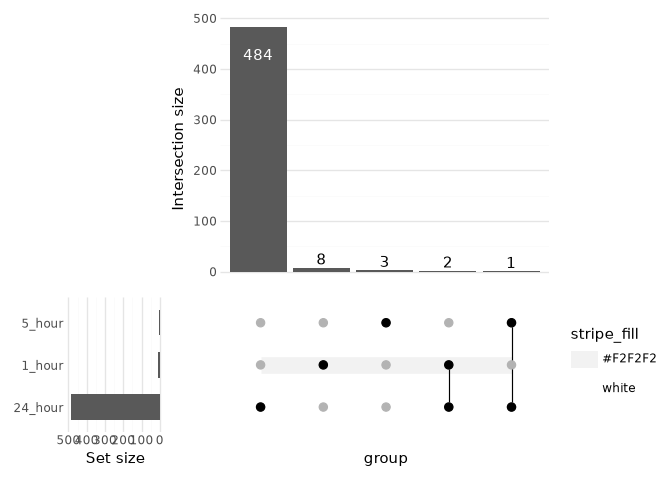

In [24]:
gg.plot_pseudobulk_de(results_by_tp, mode="upset")

## Native UpSet plots

`ggnomics.upset` is a native Plotnine set-intersection (“UpSet”) plot
implementation — no Matplotlib-based `upsetplot` dependency. See [UpSet
plots](upset.ipynb) for the full workflow (computation internals,
region-selection modes, highlighting, custom annotations, Venn helpers,
and the statistical-comparison caveats); this table is a compact
function index.

| Function | Purpose |
|------------------------------------|------------------------------------|
| `upset.upset` | High-level plot: raw data or prepared `UpSetData` -\> `Compose` |
| `upset.upset_data` / `compute_intersections` / `select_intersections` / `apply_intersection_selection` | The compute -\> select -\> apply pipeline behind `upset()` |
| `upset.intersection_size`, `upset.intersection_ratio`, `upset.upset_annotate` | Built-in and custom annotation panels |
| `upset.intersection_matrix`, `upset.upset_set_size`, `upset.upset_stripes` | Matrix, marginal set-size, and stripe styling |
| `upset.upset_query` | Highlight a set, intersection, or (not yet implemented) group |
| `upset.upset_themes`, `upset.upset_default_themes`, `upset.upset_modify_themes` | Per-component theme collections |
| `upset.compare_between_intersections`, `upset.upset_test` | Optional (`ggnomics[upset]`) statistical comparisons across intersections |
| `upset.arrange_venn`, `upset.geom_venn_circle`, `upset.geom_venn_region`, `upset.scale_fill_venn_mix`, … | Approximate 2-4 set Venn diagrams |

## Multimodal

See [Multimodal](multimodal.ipynb) for the RNA/ADT workflow and the input
requirements of `plot_adt_qc`.

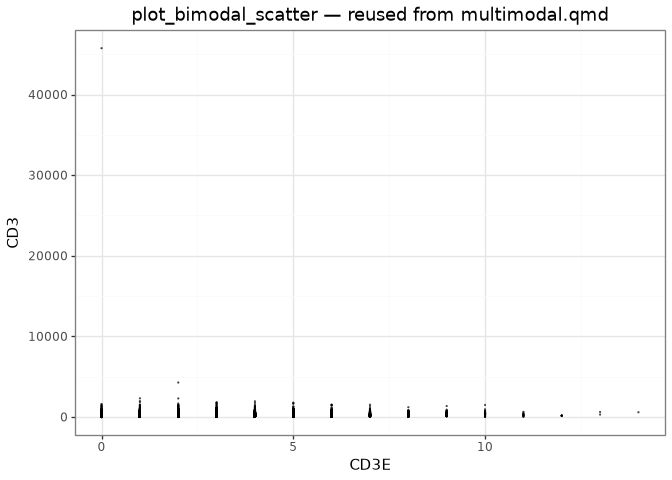

In [25]:
import mudata as mu

mu.set_options(pull_on_update=False)
mdata = mu.MuData({"rna": mods["rna"], "prot": mods["adt"]})
gg.plot_bimodal_scatter(mdata, x_feature="CD3E", y_feature="CD3", x_mod="rna", y_mod="prot") + theme_bw() + labs(title="plot_bimodal_scatter — reused from multimodal.qmd")

## Repertoire

The repertoire workflow is described in [Specialized
plots](specialized-plots.ipynb#ECCITE-seq-TCR-repertoire-(EH4616-CTCL,-EH4621-control)).

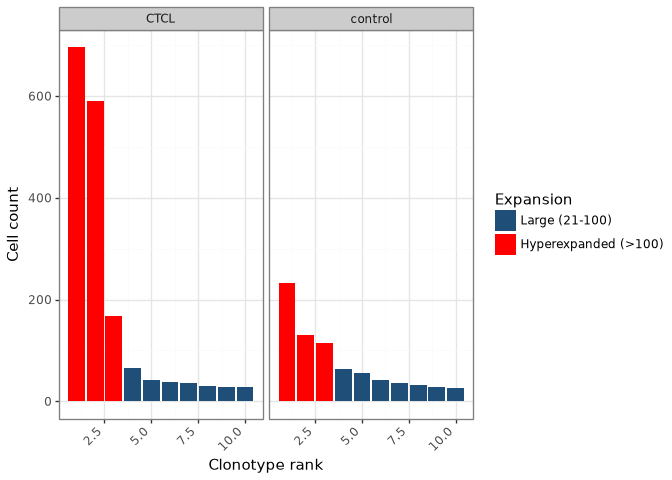

In [26]:
trb = tcr[(tcr["chain"] == "TRB") & (tcr["raw_clonotype_id"] != "None")].dropna(subset=["v_gene", "j_gene"])
cell_level = trb.drop_duplicates(subset=["barcode", "condition"])
gg.plot_clonotype_abundance(cell_level, clonotype_col="clonotype_id", sample_col="condition", top_n=10) + theme_bw() + theme(axis_text_x=element_text(rotation=45, hjust=1))

## Significance brackets (`ggnomics.signif`)

| Function              | Purpose                           |
|-----------------------|-----------------------------------|
| `geom_signif`         | ggsignif-style bracket layer/geom |
| `run_comparisons`     | Pairwise statistical tests        |
| `map_pvalue_to_stars` | p-value -\> star label            |

In [27]:
from ggnomics import run_comparisons, map_pvalue_to_stars

two_classes = cd[cd["level1class"].isin(["astrocytes_ependymal", "oligodendrocytes"])].copy()
gfap_idx = list(zeisel_final.get_row_names()).index("Gfap")
two_classes["Gfap"] = np.asarray(zeisel_final.get_assay("logcounts")[gfap_idx, :])[cd["level1class"].isin(["astrocytes_ependymal", "oligodendrocytes"]).to_numpy()]

stats_table = run_comparisons(two_classes["Gfap"], two_classes["level1class"], comparisons=[("astrocytes_ependymal", "oligodendrocytes")])
stats_table

In [28]:
[map_pvalue_to_stars(p) for p in [0.5, 0.03, 0.005, 0.0005, 0.00001]]

['ns', '*', '**', '***', '****']

Brackets remain compatible with facets and themes, as shown in
[Specialized
plots](specialized-plots.ipynb#Grouped-statistics-with-automatic-significance-brackets).

## Palettes and themes

Palette examples and IGV attribution are provided in [Specialized
plots](specialized-plots.ipynb#Custom-palettes-and-the-IGV-palette).

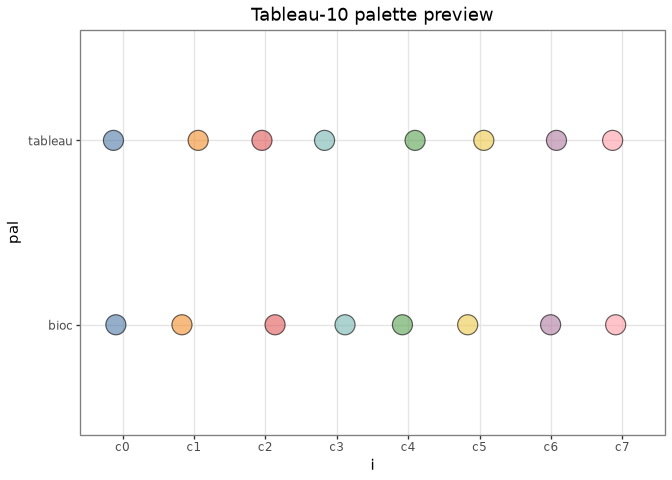

In [29]:
tableau = gg.get_palette(8, name="tableau")
bioc = gg.get_palette(8, name="bioc")
preview = pd.DataFrame({"i": [f"c{i}" for i in range(8)] * 2, "pal": ["tableau"] * 8 + ["bioc"] * 8, "v": 1})
preview["color"] = [tableau[i] for i in range(8)] + [bioc[i] for i in range(8)]
gg.plot_coldata(preview, x="i", y="pal", color_by="i", shape="point", size=8, palette={f"c{i}": tableau[i] for i in range(8)}) + theme_bw() + theme(legend_position="none") + labs(title="Tableau-10 palette preview")

In [30]:
categories = pd.Series(["astrocytes_ependymal", "oligodendrocytes", "microglia"])
gg.resolve_palette(categories, palette={"microglia": "#000000"})

{'microglia': '#000000',
 'astrocytes_ependymal': '#4E79A7',
 'oligodendrocytes': '#F28E2B'}

## Composed panels

| Function               | Purpose                                 |
|------------------------|-----------------------------------------|
| `hstack`               | Side-by-side composition                |
| `vstack`               | Vertical composition                    |
| `grid`                 | Grid layout                             |
| `annotate_composition` | Title/subtitle/caption on a composition |
| `save_composition`     | Save any composition to a file          |

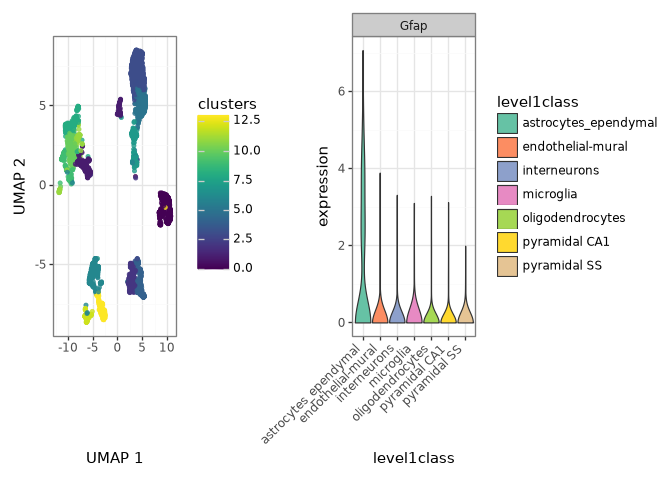

In [31]:
from ggnomics import hstack, vstack, grid, annotate_composition, save_composition

umap_p = gg.plot_umap(zeisel_final, color="clusters") + theme_bw()
violin_p = gg.plot_expression(zeisel_final, features=["Gfap"], group_by="level1class", layer="logcounts") + theme_bw() + theme(axis_text_x=element_text(rotation=45, hjust=1))

hstack(umap_p, violin_p)

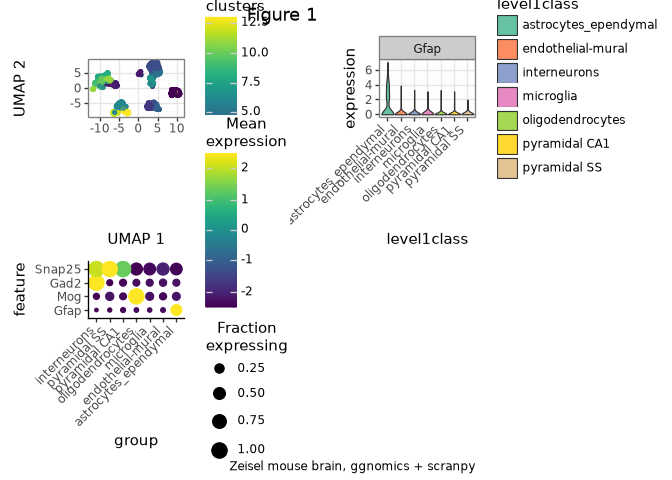

In [32]:
composed = grid([umap_p, violin_p, gg.plot_dot(zeisel_final, features=markers, group_by="level1class", layer="logcounts")], ncol=2)
annotated = annotate_composition(composed, title="Figure 1", caption="Zeisel mouse brain, ggnomics + scranpy")
annotated

In [33]:
save_composition(annotated, str(pathlib.Path("_freeze_assets") / "composed_figure_1.png"), dpi=100)

## Additional API notes

- `plot_adt_qc` requires annotated isotype controls. The CITE-seq panel
  used here does not contain them; [Multimodal
  §5](multimodal.ipynb#5.-RNA-QC-and-ADT-QC) shows the validation behaviour
  and a control-free ADT QC plot.
- The generic `ggnomics.pca` layer (`run_pca_sklearn`, `run_pca_svd`,
  and `PcaResult`) is used internally by `bulk_pca.run_pca` and
  `sc_pca.run_pca`. It is not re-exported from the top-level namespace.